In [4]:
print("I am learing Python")

I am learing Python


In [1]:
import pandas as pd

df = pd.read_csv('sales_data.csv')

df.head()

,OrderID,OrderDate,Customer,City,Category,Product,Quantity,Price,Revenue,Profit,Channel,Month
0,1001,4/16/2024,James Brown,Dallas,Electronics,Laptop,1,$293.00,$293.00,$135.15,Online,April
1,1002,2/23/2024,James Brown,Atlanta,Home,Toaster,5,$137.00,$685.00,$282.23,In-store,February
2,1003,2/23/2024,David Kim,Dallas,Electronics,Keyboard,3,$67.00,$201.00,$48.51,In-store,February
3,1004,2/19/2024,Liam Johnson,Charlotte,Clothing,Jeans,2,$405.00,$810.00,$302.27,In-store,February
4,1005,4/27/2024,Noah Martinez,Charlotte,Electronics,Monitor,2,$216.00,$432.00,$210.41,Online,April


In [5]:
df.columns

Index(['OrderID', 'OrderDate', 'Customer', 'City', 'Category', 'Product',
       'Quantity', ' Price ', ' Revenue ', ' Profit ', 'Channel', 'Month'],
      dtype='str')

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df[ 'Revenue' ].sum()

' $293.00  $685.00  $201.00  $810.00  $432.00  $522.00  $2,340.00  $1,128.00  $376.00  $69.00  $1,855.00  $990.00  $452.00  $2,110.00  $46.00  $236.00  $134.00  $546.00  $1,092.00  $1,004.00  $1,182.00  $332.00  $438.00  $1,335.00  $891.00  $321.00  $1,205.00  $2,230.00  $1,155.00  $1,032.00  $278.00  $403.00  $1,344.00  $50.00  $457.00  $606.00  $264.00  $1,080.00  $1,400.00  $394.00  $171.00  $1,770.00  $155.00  $330.00  $494.00  $290.00  $1,604.00  $195.00  $384.00  $1,660.00  $1,224.00  $970.00  $782.00  $395.00  $618.00  $1,116.00  $88.00  $406.00  $1,825.00  $429.00  $505.00  $252.00  $708.00  $2,060.00  $454.00  $644.00  $406.00  $112.00  $438.00  $596.00  $735.00  $432.00  $420.00  $1,176.00  $317.00  $476.00  $1,326.00  $662.00  $96.00  $1,192.00  $1,935.00  $540.00  $864.00  $288.00  $345.00  $1,650.00  $909.00  $406.00  $24.00  $600.00  $472.00  $101.00  $747.00  $1,124.00  $786.00  $1,900.00  $364.00  $802.00  $1,242.00  $204.00  $298.00  $570.00  $84.00  $790.00  $226.00  

In [11]:
df['Revenue'] = df['Revenue'].replace(r'[\$,]', '', regex=True).astype(float)
df['Profit'] = df['Profit'].replace(r'[\$,]', '', regex=True).astype(float)

In [12]:
df[['Revenue', 'Profit']].head()

,Revenue,Profit
0,293.0,135.15
1,685.0,282.23
2,201.0,48.51
3,810.0,302.27
4,432.0,210.41


In [13]:
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()

total_revenue, total_profit

(np.float64(376012.0), np.float64(132096.68))

In [14]:
city_sales = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)
product_profit = df.groupby('Product')['Profit'].sum().sort_values(ascending=False)
category_sales = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

In [15]:
import matplotlib.pyplot as plt

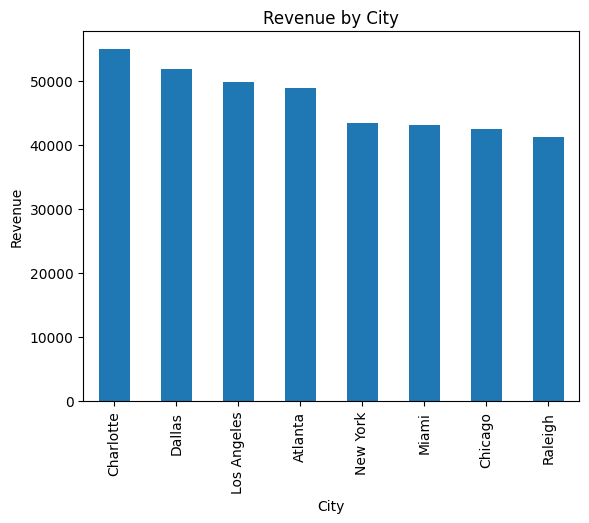

In [16]:
city_sales.plot(kind='bar')
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

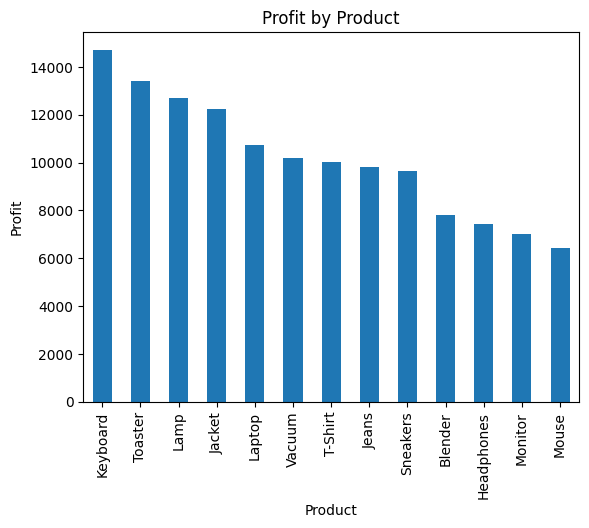

In [17]:
product_profit.plot(kind='bar')
plt.title('Profit by Product')
plt.xlabel('Product')
plt.ylabel('Profit')
plt.show()

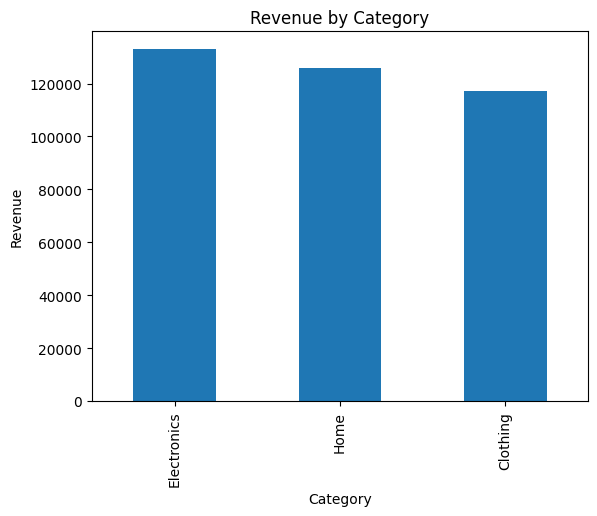

In [18]:
category_sales.plot(kind='bar')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

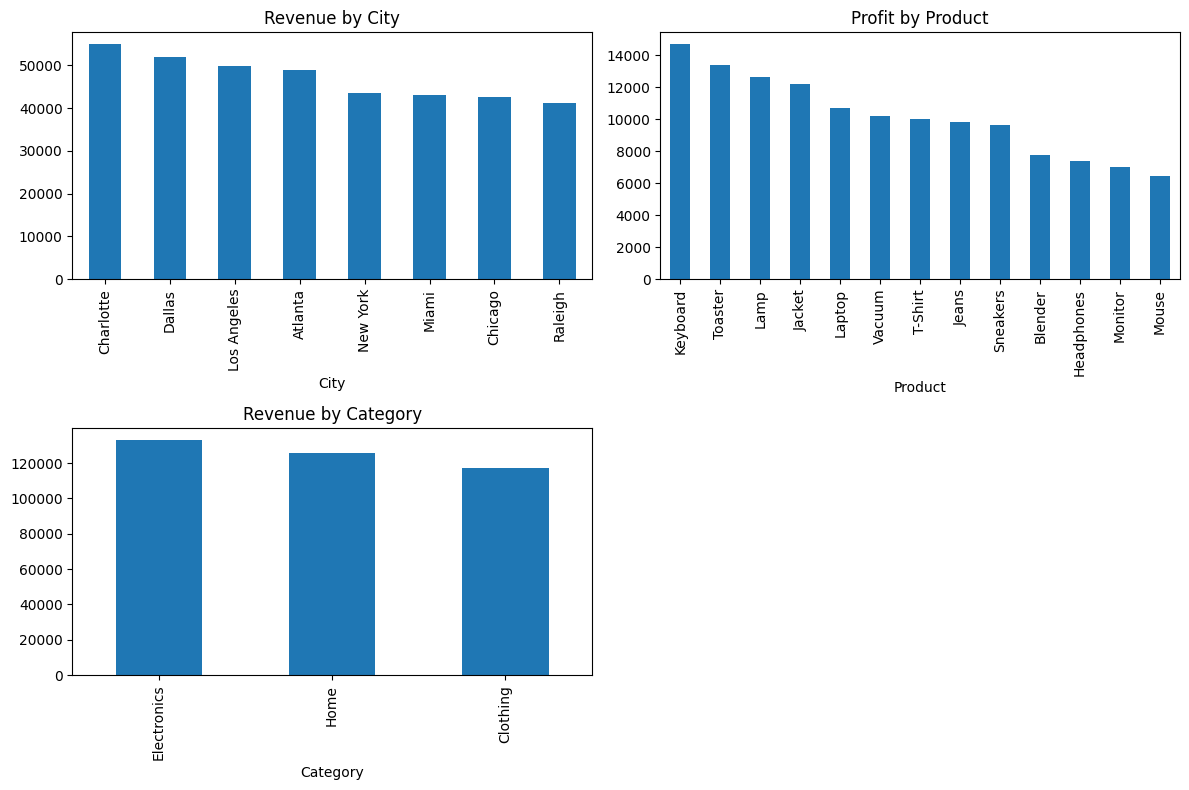

In [19]:
plt.figure(figsize=(12,8))

# Chart 1: Revenue by City
plt.subplot(2,2,1)
city_sales.plot(kind='bar')
plt.title('Revenue by City')

# Chart 2: Profit by Product
plt.subplot(2,2,2)
product_profit.plot(kind='bar')
plt.title('Profit by Product')

# Chart 3: Revenue by Category
plt.subplot(2,2,3)
category_sales.plot(kind='bar')
plt.title('Revenue by Category')

plt.tight_layout()
plt.show()

In [20]:
print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)

Total Revenue: 376012.0
Total Profit: 132096.68


In [22]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
sns.set_style("whitegrid")

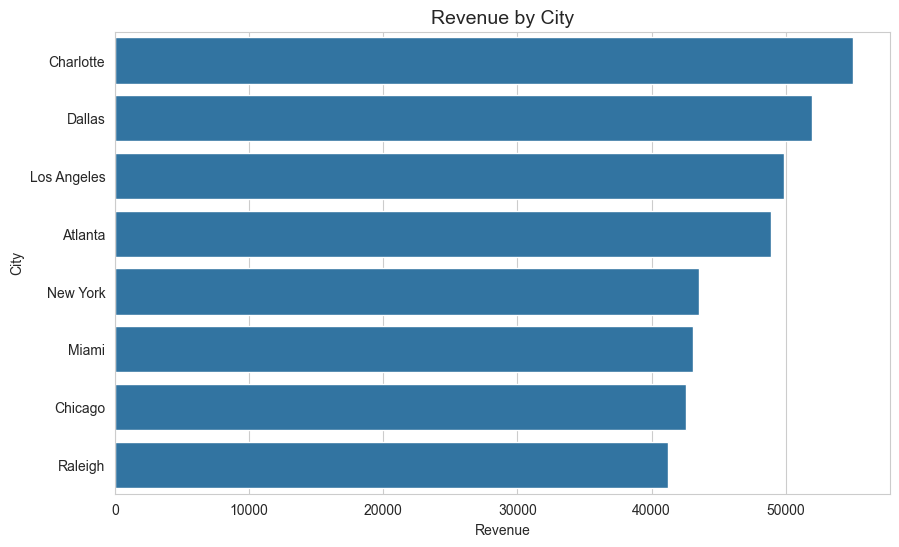

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title('Revenue by City', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('City')

plt.show()

In [26]:
print("Top City:", city_sales.idxmax())
print("Top Product:", product_profit.idxmax())
print("Top Category:", category_sales.idxmax())

Top City: Charlotte
Top Product: Keyboard
Top Category: Electronics


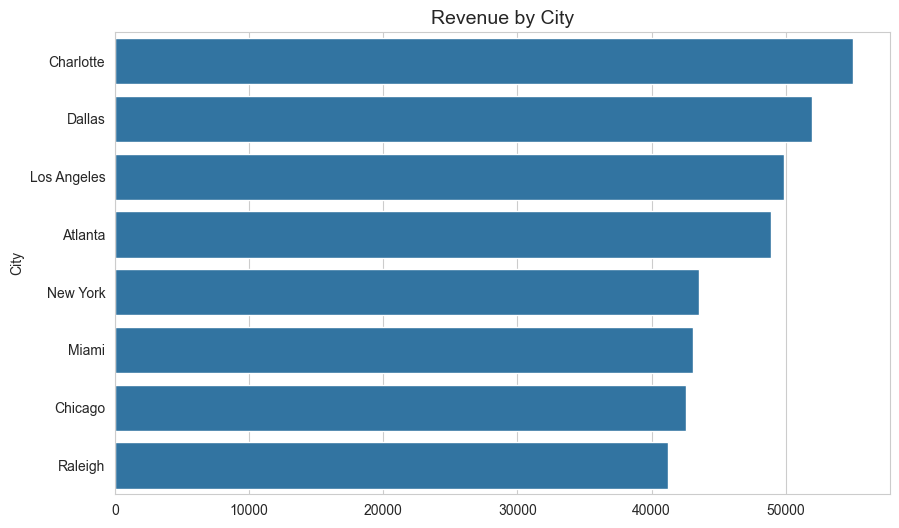

In [27]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title('Revenue by City', fontsize=14)

plt.savefig('revenue_by_city.png')  # 👈 saves image

plt.show()

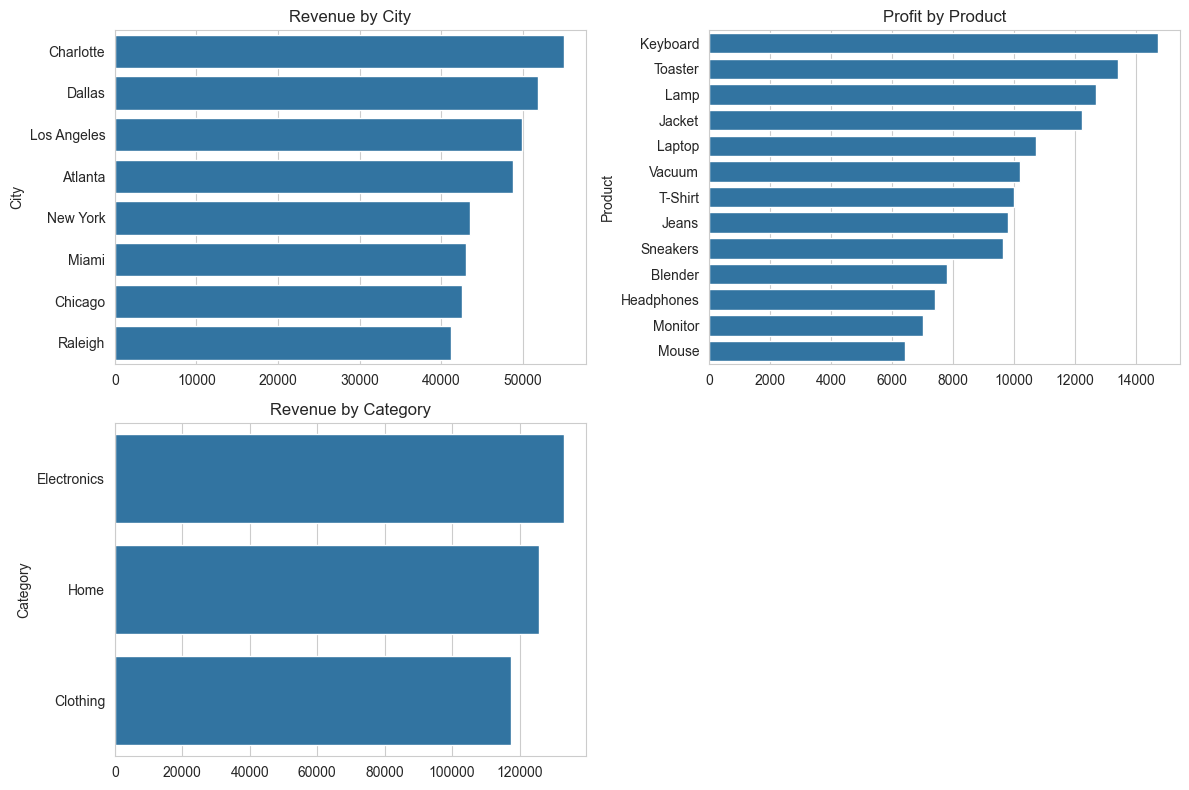

In [28]:
plt.figure(figsize=(12,8))
sns.set_style("whitegrid")

# Chart 1
plt.subplot(2,2,1)
sns.barplot(x=city_sales.values, y=city_sales.index)
plt.title('Revenue by City')

# Chart 2
plt.subplot(2,2,2)
sns.barplot(x=product_profit.values, y=product_profit.index)
plt.title('Profit by Product')

# Chart 3
plt.subplot(2,2,3)
sns.barplot(x=category_sales.values, y=category_sales.index)
plt.title('Revenue by Category')

plt.tight_layout()
plt.savefig('sales_dashboard.png')  # 👈 BIG file for portfolio

plt.show()